In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful!")

✅ All imports successful!


In [3]:
df = pd.read_csv('../data/processed/dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (1580, 12)

Column names:
['id', 'text', 'label', 'source', 'word_count', 'char_count', 'has_emoji', 'has_em_dash', 'has_ellipsis', 'starts_with_verb', 'has_buzzwords', 'collection_date']

First 5 rows:


,id,text,label,source,word_count,char_count,has_emoji,has_em_dash,has_ellipsis,starts_with_verb,has_buzzwords,collection_date
0,1,The pandemic showed us strength is found in co...,1,ai_copilot,16,102,no,no,no,no,no,2026-03-18
1,2,"Every pop song is a reminder that joy, heartbr...",1,ai_copilot,15,89,no,no,no,no,no,2026-03-18
2,3,Ocean dive adventure shared with @dive_master_...,1,ai_perplexity,8,66,no,yes,no,no,no,2026-03-18
3,4,I went to the beach and got my head stuck insi...,0,human_instagram,13,57,no,no,no,no,no,2026-03-18
4,5,Never loved a saree as much as this one💛 Weari...,0,human_instagram,11,73,yes,no,no,no,no,2026-03-18


In [4]:
print("=== CLASS DISTRIBUTION ===")
print(df['label'].value_counts())
print(f"\nBalance ratio: {df['label'].value_counts()[0] / df['label'].value_counts()[1]:.2f}")

print("\n=== SOURCE BREAKDOWN ===")
print(df['source'].value_counts())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

=== CLASS DISTRIBUTION ===
label
1    790
0    790
Name: count, dtype: int64

Balance ratio: 1.00

=== SOURCE BREAKDOWN ===
source
human_instagram    790
ai_chatgpt         245
ai_gemini          218
ai_copilot         138
ai_perplexity       87
Name: count, dtype: int64

=== MISSING VALUES ===
id                    0
text                  0
label                 0
source              102
word_count            0
char_count            0
has_emoji             0
has_em_dash           0
has_ellipsis          0
starts_with_verb      0
has_buzzwords         0
collection_date       0
dtype: int64

=== DATA TYPES ===
id                  int64
text                  str
label               int64
source                str
word_count          int64
char_count          int64
has_emoji             str
has_em_dash           str
has_ellipsis          str
starts_with_verb      str
has_buzzwords         str
collection_date       str
dtype: object


In [5]:
print("=== WORD COUNT STATS ===")
print(df.groupby('label')['word_count'].describe().round(2))

print("\n=== CHAR COUNT STATS ===")
print(df.groupby('label')['char_count'].describe().round(2))

=== WORD COUNT STATS ===
       count   mean    std  min   25%   50%   75%    max
label                                                   
0      790.0  20.36  19.32  5.0  10.0  14.0  24.0  204.0
1      790.0  21.11  12.72  5.0  15.0  20.0  23.0   95.0

=== CHAR COUNT STATS ===
       count    mean     std   min   25%    50%     75%     max
label                                                          
0      790.0  112.90  106.92  14.0  53.0   80.0  133.75  1069.0
1      790.0  138.36   91.86  28.0  97.0  120.0  154.00   658.0


In [6]:
# Fill missing source values
df['source'] = df['source'].fillna('unknown')

print("Missing values after fix:")
print(df.isnull().sum())
print(f"\nSource breakdown after fix:")
print(df['source'].value_counts())

Missing values after fix:
id                  0
text                0
label               0
source              0
word_count          0
char_count          0
has_emoji           0
has_em_dash         0
has_ellipsis        0
starts_with_verb    0
has_buzzwords       0
collection_date     0
dtype: int64

Source breakdown after fix:
source
human_instagram    790
ai_chatgpt         245
ai_gemini          218
ai_copilot         138
unknown            102
ai_perplexity       87
Name: count, dtype: int64


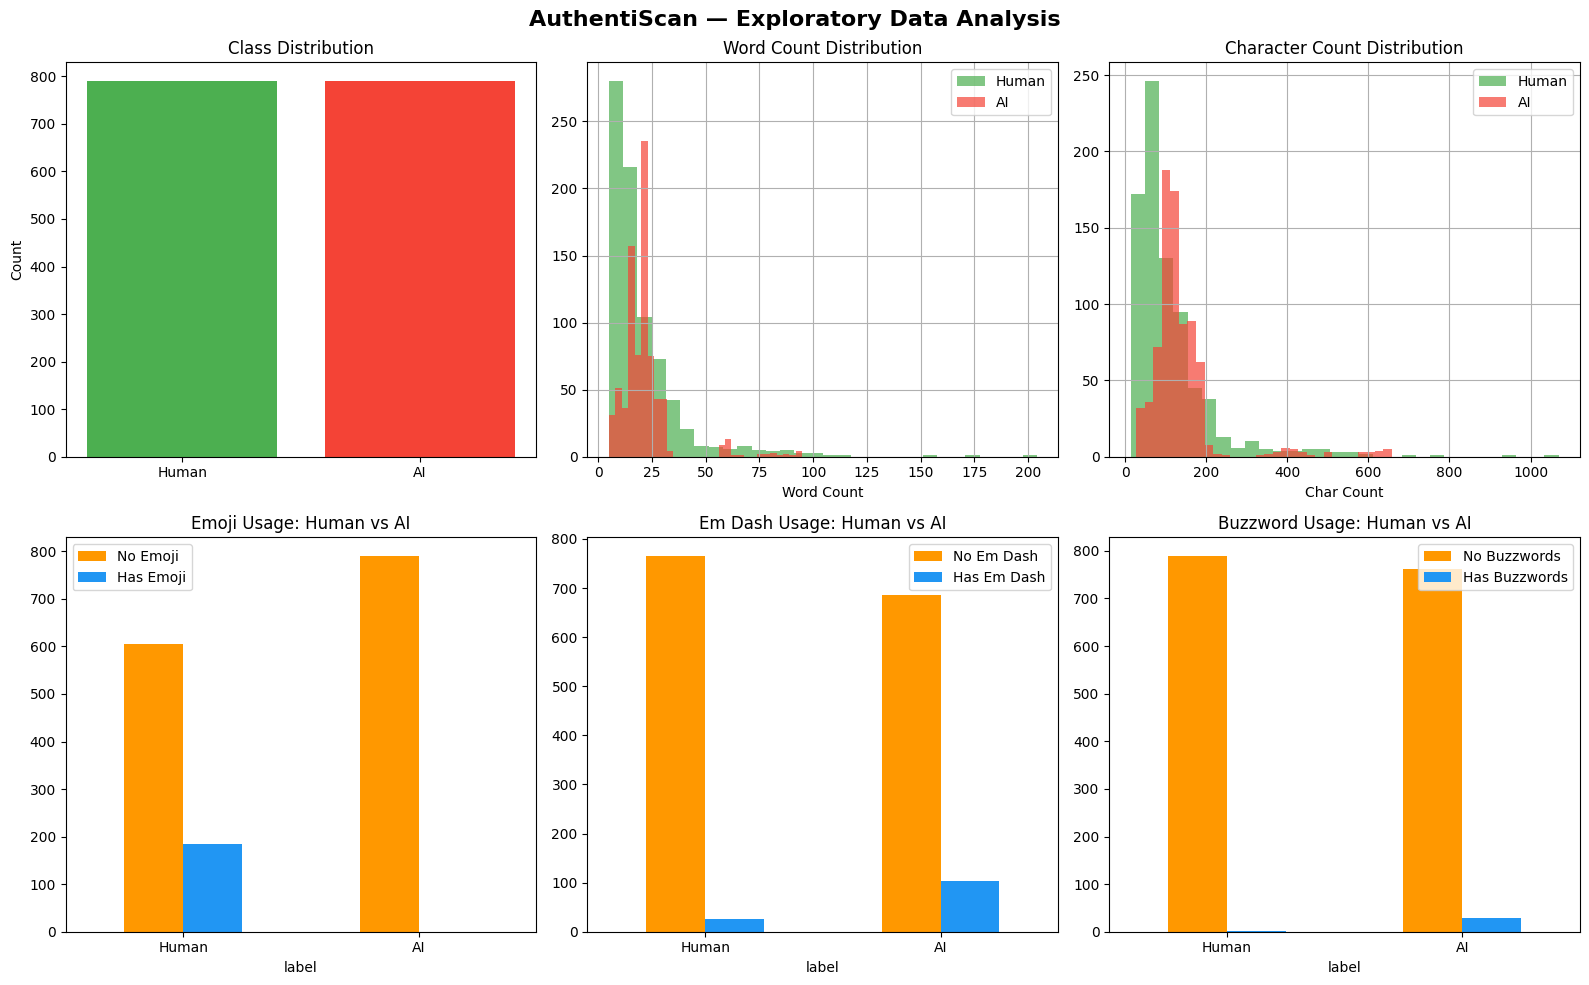

✅ EDA plots saved to results/eda_plots.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('AuthentiScan — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Class distribution
axes[0,0].bar(['Human', 'AI'], df['label'].value_counts().values, color=['#4CAF50', '#F44336'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')

# 2. Word count distribution
df[df['label']==0]['word_count'].hist(ax=axes[0,1], bins=30, alpha=0.7, color='#4CAF50', label='Human')
df[df['label']==1]['word_count'].hist(ax=axes[0,1], bins=30, alpha=0.7, color='#F44336', label='AI')
axes[0,1].set_title('Word Count Distribution')
axes[0,1].set_xlabel('Word Count')
axes[0,1].legend()

# 3. Char count distribution
df[df['label']==0]['char_count'].hist(ax=axes[0,2], bins=30, alpha=0.7, color='#4CAF50', label='Human')
df[df['label']==1]['char_count'].hist(ax=axes[0,2], bins=30, alpha=0.7, color='#F44336', label='AI')
axes[0,2].set_title('Character Count Distribution')
axes[0,2].set_xlabel('Char Count')
axes[0,2].legend()

# 4. Emoji usage
emoji_data = df.groupby(['label', 'has_emoji']).size().unstack()
emoji_data.plot(kind='bar', ax=axes[1,0], color=['#FF9800', '#2196F3'])
axes[1,0].set_title('Emoji Usage: Human vs AI')
axes[1,0].set_xticklabels(['Human', 'AI'], rotation=0)
axes[1,0].legend(['No Emoji', 'Has Emoji'])

# 5. Em dash usage
emdash_data = df.groupby(['label', 'has_em_dash']).size().unstack()
emdash_data.plot(kind='bar', ax=axes[1,1], color=['#FF9800', '#2196F3'])
axes[1,1].set_title('Em Dash Usage: Human vs AI')
axes[1,1].set_xticklabels(['Human', 'AI'], rotation=0)
axes[1,1].legend(['No Em Dash', 'Has Em Dash'])

# 6. Buzzword usage
buzzword_data = df.groupby(['label', 'has_buzzwords']).size().unstack()
buzzword_data.plot(kind='bar', ax=axes[1,2], color=['#FF9800', '#2196F3'])
axes[1,2].set_title('Buzzword Usage: Human vs AI')
axes[1,2].set_xticklabels(['Human', 'AI'], rotation=0)
axes[1,2].legend(['No Buzzwords', 'Has Buzzwords'])

plt.tight_layout()
plt.savefig('../results/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved to results/eda_plots.png")

In [9]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)             # remove mentions
    text = re.sub(r'\s+', ' ', text).strip()     # extra spaces
    return text

df['clean_text'] = df['text'].apply(clean_text)

print("✅ Text cleaned!")
print(f"\nOriginal : {df['text'][0]}")
print(f"Cleaned  : {df['clean_text'][0]}")

✅ Text cleaned!

Original : The pandemic showed us strength is found in community, not isolation, and healing begins with empathy.
Cleaned  : the pandemic showed us strength is found in community, not isolation, and healing begins with empathy.


In [10]:
# Convert yes/no columns to binary 0/1
binary_cols = ['has_emoji', 'has_em_dash', 'has_ellipsis', 'starts_with_verb', 'has_buzzwords']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Build handcrafted feature matrix
handcrafted_features = df[['word_count', 'char_count'] + binary_cols].values

print(f"✅ Handcrafted features shape: {handcrafted_features.shape}")
print(f"Features: word_count, char_count, {', '.join(binary_cols)}")

✅ Handcrafted features shape: (1580, 7)
Features: word_count, char_count, has_emoji, has_em_dash, has_ellipsis, starts_with_verb, has_buzzwords


In [ ]:
#TF-IDF Features

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)
tfidf_features = tfidf.fit_transform(df['clean_text'])

print(f"✅ TF-IDF features shape: {tfidf_features.shape}")

✅ TF-IDF features shape: (1580, 5000)


In [ ]:
#SBERT Features

from sentence_transformers import SentenceTransformer

print("Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings... (may take a minute)")
sbert_features = sbert_model.encode(df['clean_text'].tolist(), 
                                     show_progress_bar=True,
                                     batch_size=64)

print(f"✅ SBERT features shape: {sbert_features.shape}")

Loading SBERT model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2104.42it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings... (may take a minute)


Batches:  76%|███████▌  | 19/25 [00:18<00:02,  2.44it/s]